In [1]:
# === FINAL 3-Channel BiGRU Pipeline with SMOTE + Derivatives ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
# === STEP 0: Configuration ===
segment_length = 1200
segmented_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/1D-CNN-UC-FHR'


In [3]:
# === STEP 1: Load and Augment Data ===
X_raw, y = [], []
for class_label in ['class_0', 'class_1']:
    label = int(class_label.split('_')[1])
    path = os.path.join(segmented_dir, class_label)
    for file in os.listdir(path):
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(path, file))
            if 'FHR_denoised' not in df.columns or 'UC' not in df.columns:
                continue
            fhr = df['FHR_denoised'].values
            uc = df['UC'].values
            fhr_diff = np.diff(fhr, prepend=fhr[0])

            signal = np.stack([fhr, uc, fhr_diff], axis=1)
            if signal.shape != (segment_length, 3):
                continue

            # Normalize each channel
            for i in range(3):
                col = signal[:, i]
                if np.max(col) - np.min(col) != 0:
                    signal[:, i] = (col - np.min(col)) / (np.max(col) - np.min(col))

            X_raw.append(signal)
            y.append(label)


In [4]:
X = np.array(X_raw)
y = np.array(y)

# === STEP 2: Apply SMOTE to balance ===
X_flat = X.reshape((X.shape[0], -1))
X_resampled, y_resampled = SMOTE().fit_resample(X_flat, y)
X_resampled = X_resampled.reshape((-1, 1200, 3))

X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)


In [5]:
# === STEP 3: Build Model ===
model = Sequential([
    Conv1D(64, kernel_size=5, activation='relu', input_shape=(1200, 3)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Bidirectional(GRU(128)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1196, 64)          1024      
                                                                 
 batch_normalization (BatchN  (None, 1196, 64)         256       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 598, 64)          0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 598, 64)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 596, 128)          24704     
                                                                 
 batch_normalization_1 (Batc  (None, 596, 128)         5

In [6]:
# === STEP 4: Train ===
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks
)


Epoch 1/50
308/308 [==============================] - 105s 323ms/step - loss: 0.7023 - accuracy: 0.5487 - val_loss: 0.9953 - val_accuracy: 0.5041 - lr: 5.0000e-04
Epoch 2/50
308/308 [==============================] - 94s 304ms/step - loss: 0.6821 - accuracy: 0.5768 - val_loss: 0.8359 - val_accuracy: 0.5155 - lr: 5.0000e-04
Epoch 3/50
308/308 [==============================] - 93s 303ms/step - loss: 0.6731 - accuracy: 0.5869 - val_loss: 0.7465 - val_accuracy: 0.5362 - lr: 5.0000e-04
Epoch 4/50
308/308 [==============================] - 92s 300ms/step - loss: 0.6717 - accuracy: 0.5854 - val_loss: 0.7016 - val_accuracy: 0.5773 - lr: 5.0000e-04
Epoch 5/50
308/308 [==============================] - 93s 301ms/step - loss: 0.6621 - accuracy: 0.6079 - val_loss: 0.6722 - val_accuracy: 0.5976 - lr: 5.0000e-04
Epoch 6/50
308/308 [==============================] - 93s 302ms/step - loss: 0.6525 - accuracy: 0.6162 - val_loss: 0.6516 - val_accuracy: 0.6318 - lr: 5.0000e-04
Epoch 7/50
308/308 [=======

In [7]:
# === STEP 5: Evaluation ===
y_scores = model.predict(X_val).flatten()

best_thresh = 0.5
best_f1 = 0
for t in np.arange(0.1, 0.9, 0.01):
    preds = (y_scores > t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_thresh = t
        best_f1 = f1

print(f"\n=== Best Threshold by F1: {best_thresh:.2f} ===")
y_pred = (y_scores > best_thresh).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_val, y_pred, digits=4))

77/77 [==============================] - 6s 53ms/step

=== Best Threshold by F1: 0.45 ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9150    0.7705    0.8366      1229
           1     0.8018    0.9284    0.8605      1229

    accuracy                         0.8495      2458
   macro avg     0.8584    0.8495    0.8485      2458
weighted avg     0.8584    0.8495    0.8485      2458



In [8]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))


Confusion Matrix:
[[ 947  282]
 [  88 1141]]


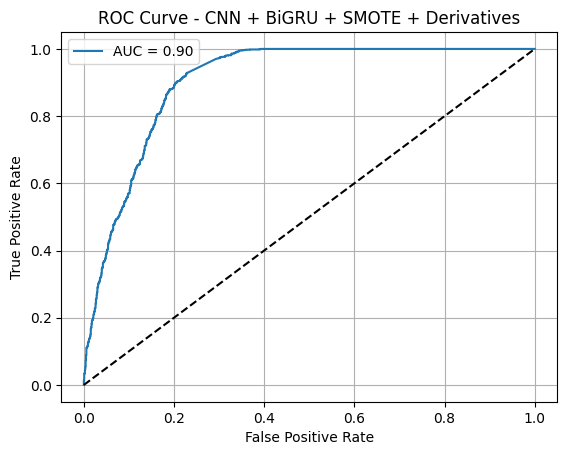

In [9]:
# === STEP 6: ROC Curve ===
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN + BiGRU + SMOTE + Derivatives')
plt.legend()
plt.grid(True)
plt.show()

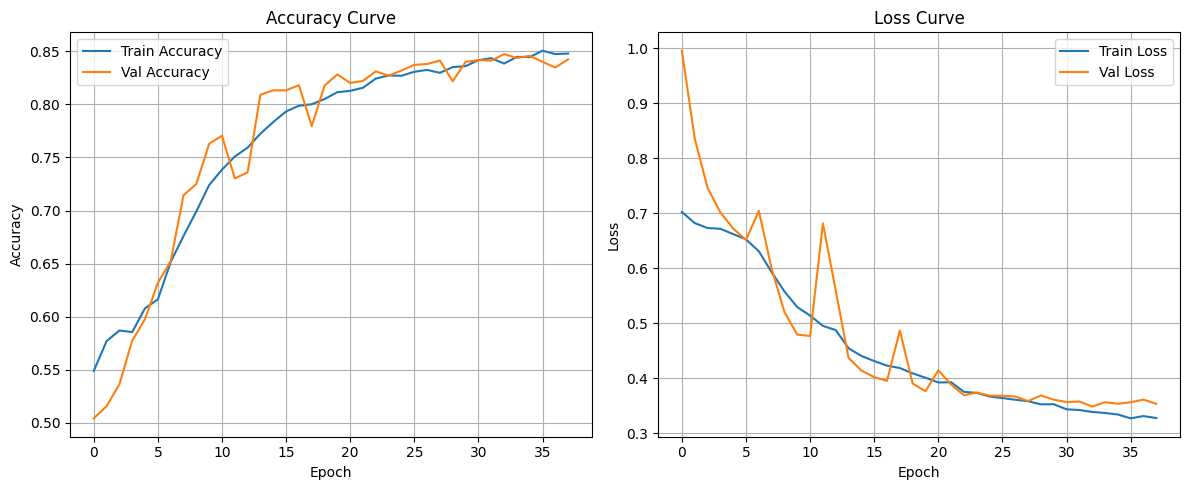

In [10]:
# === STEP 7: Accuracy & Loss Curves ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
